# Podstawowa klasyfikacja obrazów za pomocą sieci splotowych


In [1]:
import os

# Ustawienie PyTorch jako zaplecza dla biblioteki Keras
os.environ["KERAS_BACKEND"] = "torch"

# PyTorch i tf.keras
#import tensorflow as tf
import torch
import keras
from keras import datasets,callbacks

# Biblioteki pomocnicze
import numpy as np
import matplotlib.pyplot as plt

#print(tf.__version__)
print(keras.__version__)
print(torch.__version__)

# Sprawdzenie dostępności GPU
#print(tf.config.list_physical_devices('GPU'))
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(f"GPU {i}: {torch.cuda.get_device_name(i)}")
else:
    if torch.xpu.is_available():
        for i in range(torch.xpu.device_count()):
            print(f"XPU {i}: {torch.xpu.get_device_name(i)}")
    else:
        print("Brak dostępnych GPU lub XPU.")
        print("Używam CPU.")
        
#keras.backend.set_floatx("float16")

3.11.3
2.9.1+cpu
Brak dostępnych GPU lub XPU.
Używam CPU.


## Import i wstępne przygotowanie danych



In [2]:
(train_images, train_labels), (test_images, test_labels) = datasets.mnist.load_data()
train_images = train_images / 255.0
test_images = test_images / 255.0

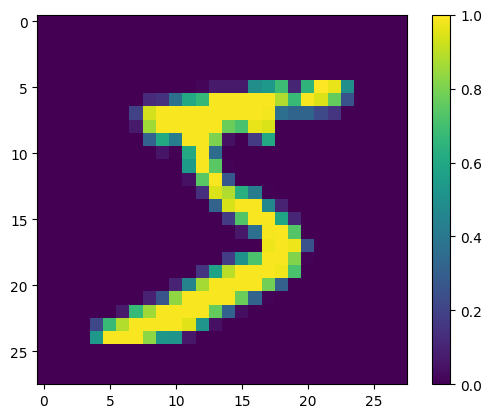

(28, 28, 1)


In [3]:
plt.figure()
plt.imshow(train_images[0])
plt.colorbar()
plt.grid(False)
plt.show()

input_shape = train_images[0].shape
if len(input_shape) < 3:
    input_shape += tuple([1])
print(input_shape)

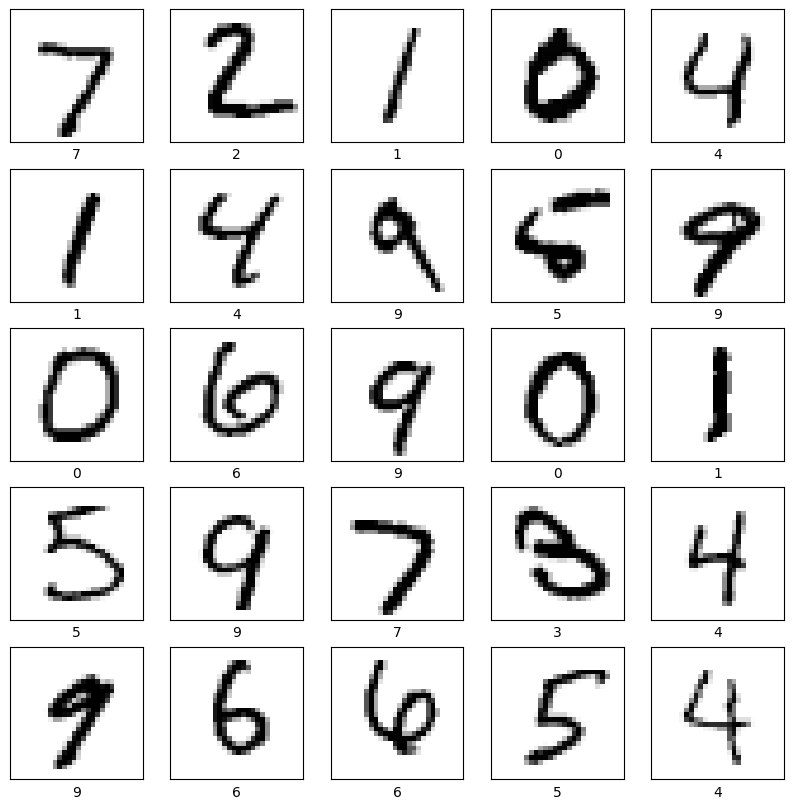

In [4]:
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(test_images[i], cmap=plt.cm.binary)
    plt.xlabel(test_labels[i])
plt.show()

## Budowa modelu

In [66]:
def simple_classifier(classifier = keras.Sequential([]), classifier_input = ()):
    classifier.add(keras.layers.Flatten(input_shape=classifier_input))
    classifier.add(keras.layers.Dense(84, activation='tanh'))
    classifier.add(keras.layers.Dense(10, activation='softmax'))
    return classifier

def lenet_5(lenet = keras.Sequential([]), classifier_input = ()):
    lenet.add(keras.layers.Conv2D(6, kernel_size=(5, 5), strides=1, padding='same', activation='tanh', input_shape=classifier_input))
    lenet.add(keras.layers.AveragePooling2D(pool_size=2, strides = 2, padding ='valid'))
    lenet.add(keras.layers.Conv2D(16, kernel_size=(5, 5), strides=1, padding='valid', activation='tanh'))
    lenet.add(keras.layers.AveragePooling2D(pool_size=2, strides = 2, padding ='valid'))
    lenet.add(keras.layers.Conv2D(120, kernel_size=(5, 5), strides=1, padding='valid', activation='tanh'))
    simple_classifier(lenet)
    return lenet

model = simple_classifier(classifier_input=input_shape)
model.summary()

Model: "sequential_30"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_15 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 84)             │        65,940 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 66,790 (260.90 KB)

 Trainable params: 66,790 (260.90 KB)

 Non-trainable params: 0 (0.00 B)

In [68]:
model.compile(optimizer=keras.optimizers.SGD(learning_rate=0.1),
              loss=keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])

def lr_schedule(epoch):
    if epoch <= 2:
        lr = 5e-4
    elif epoch > 2 and epoch <= 5:
        lr = 2e-4
    elif epoch > 5 and epoch <= 9:
        lr = 5e-5
    else: 
        lr = 1e-5
    return lr

lr_reducer = callbacks.LearningRateScheduler(lr_schedule)

## Trening

In [69]:
history = model.fit(train_images, train_labels, epochs=20, 
                    validation_data=(test_images, test_labels), 
                    #callbacks=[lr_reducer], 
                    batch_size=32)

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9057 - loss: 0.3288 - val_accuracy: 0.9410 - val_loss: 0.2033
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9469 - loss: 0.1814 - val_accuracy: 0.9559 - val_loss: 0.1493
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9617 - loss: 0.1337 - val_accuracy: 0.9630 - val_loss: 0.1234
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9690 - loss: 0.1068 - val_accuracy: 0.9686 - val_loss: 0.1052
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9741 - loss: 0.0889 - val_accuracy: 0.9709 - val_loss: 0.0958
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9784 - loss: 0.0763 - val_accuracy: 0.9736 - val_loss: 0.0875
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9813 - loss: 0.0663 - val_accuracy: 0.9745 - val_loss: 0.0825
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9838 - loss: 0.0582 - 

### Ocena skuteczności

313/313 - 1s - 2ms/step - accuracy: 0.9774 - loss: 0.0713

Testowa skuteczność: 0.977400004863739


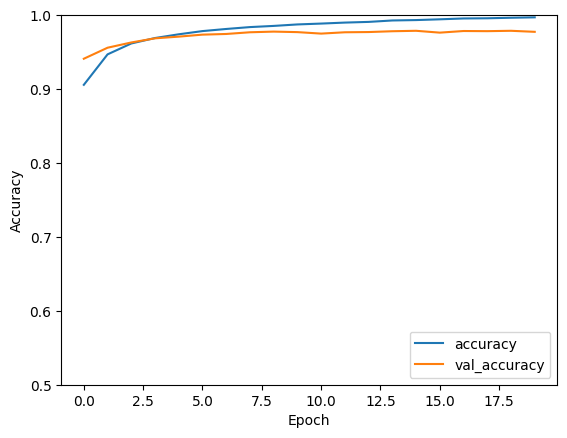

In [70]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')

test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)

print('\nTestowa skuteczność:', test_acc)

### Sprawdzenie predykcji

In [71]:
predictions = model.predict(test_images)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


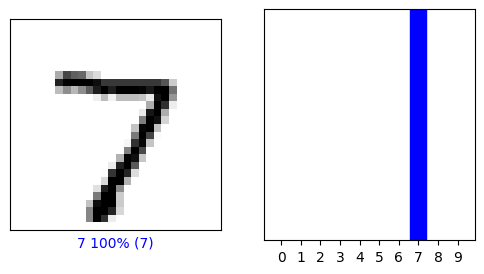

In [74]:
def plot_image(img_number, predictions_array, true_label, img):
  true_label, img = true_label[img_number], img[img_number]
  plt.grid(False)
  plt.xticks([])
  plt.yticks([])

  plt.imshow(img, cmap=plt.cm.binary)

  predicted_label = np.argmax(predictions_array)
  if predicted_label == true_label:
    color = 'blue'
  else:
    color = 'red'

  plt.xlabel("{} {:2.0f}% ({})".format(predicted_label,
                                100*np.max(predictions_array),
                                true_label),
                                color=color)

def plot_value_array(img_number, predictions_array, true_label):
  true_label = true_label[img_number]
  plt.grid(False)
  plt.xticks(range(10))
  plt.yticks([])
  this_plot = plt.bar(range(10), predictions_array, color="#777777")
  plt.ylim([0, 1])
  predicted_label = np.argmax(predictions_array)

  this_plot[predicted_label].set_color('red')
  this_plot[true_label].set_color('blue')

i = 0
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plot_image(i, predictions[i], test_labels, test_images)
plt.subplot(1,2,2)
plot_value_array(i, predictions[i],  test_labels)
plt.show()

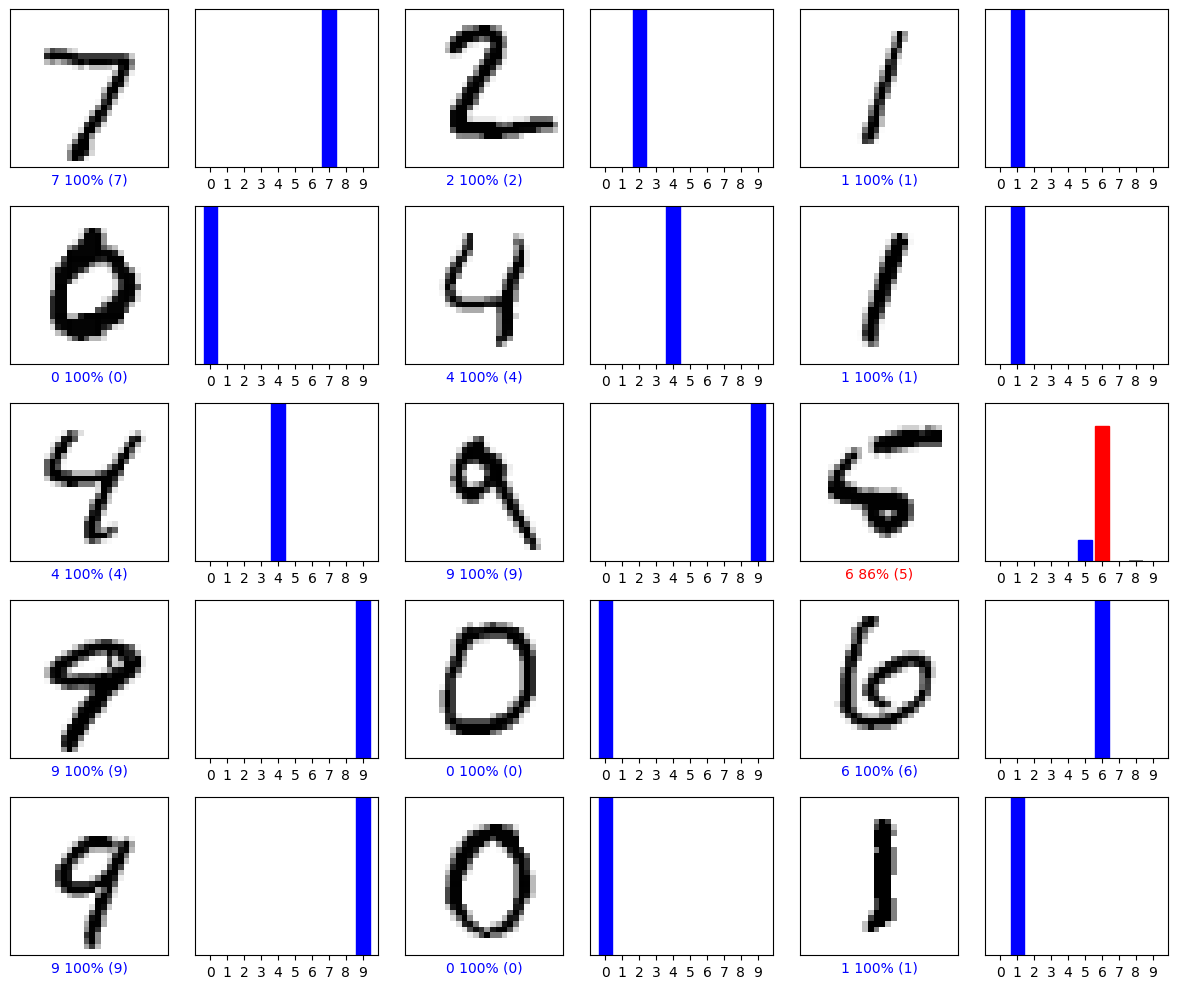

In [75]:
num_rows = 5
num_cols = 3
num_images = num_rows*num_cols
plt.figure(figsize=(2*2*num_cols, 2*num_rows))

for i in range(num_images):
  plt.subplot(num_rows, 2*num_cols, 2*i+1)
  plot_image(i, predictions[i], test_labels, test_images)
  plt.subplot(num_rows, 2*num_cols, 2*i+2)
  plot_value_array(i, predictions[i], test_labels)
  
plt.tight_layout()
plt.show()

## Zadania
1. Wytrenuj klasyfikator LeNet-5 używając funkcji aktywacji Sigmoid zamiast Tanh. (1 pkt.)
2. Zamień jedną z warstw splotowych na warstwę pełną, tak, żeby całkowita liczba parametrów sieci nie uległa zmianie a jakość klasyfikacji polepszyła się. (1 pkt.)
3. Unowocześnij sieć LeNet-5 poprzez zastąpinie: (1 pkt)
    - warstwy sumy uśrednionej przez sumę maksimum
    - funkcji aktywacji Sigmoid przez ReLU
4. Zmodyfikuj pętlę wyświetlającą predykcje tak, aby pokazywała wyłącznie błędne przypadki. (1 pkt)
5. Załaduj zbiór Fashion-MNIST i zmień rozmiary wybranych spośród wymienionych elementów sieci LeNet-5, tak aby poprawić wynik. (1 pkt)
    - rozmiar okna splotu
    - liczba kanałów wyjściowych w poszczególnych warstwach
    - liczba warstw splotowych
    - liczba warstw w pełni połączonych
    - współczynnik uczenia i pozostałe parametry treningu takie jak liczba epok, rozmiar wsadu (ang. batch size) czy optymalizator